<a href="https://colab.research.google.com/github/evelynshashik04/sparse_data_computer_vision/blob/main/.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#mount drive


let's start!
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 207MB/s]


Total parameters: 10,849,932
Best val acc: 0.7009345794392523 at epoch 29


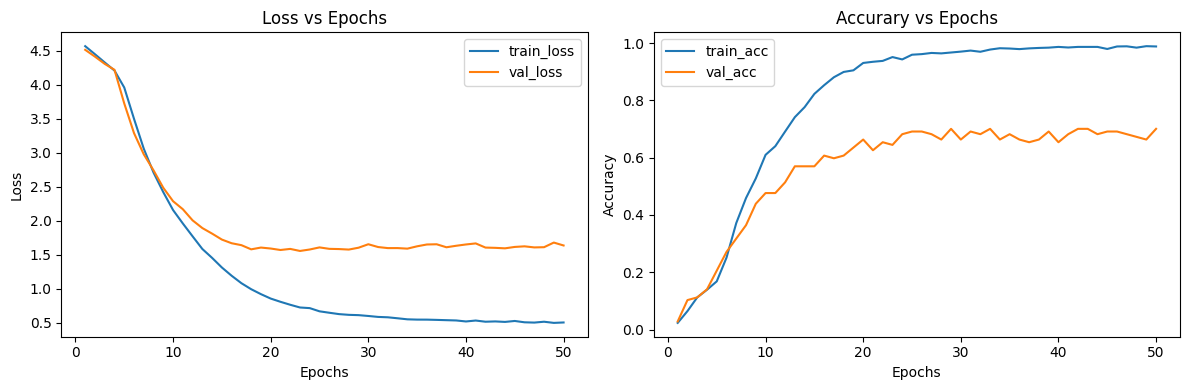

Test loss: 1.6044 | Test acc: 0.7009


In [2]:
#initial download
print("let's start!")
!pip -q install pandas numpy matplotlib torch torchvision scikit-learn tqdm Pillow
import os
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset, ConcatDataset
device = "cuda" if torch.cuda.is_available() else "cpu"

def set_seed(seed: int = 42):
    """Make results as reproducible as possible across runs."""
    #os.environ["PYTHONHASHSEED"] = str(seed)
    # If you later switch to CUDA and want maximal determinism:
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

set_seed(42)

# try data/ if the line below doesn't work!
data_dir_absolute = "/content/drive/MyDrive/data"
training_dir = os.path.join(data_dir_absolute, "train")
testing_dir = os.path.join(data_dir_absolute, "test")
ckpt_path = "./checkpoints/best_mnist_cnn.pt"
os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)#

img_size = 224
batch_size = 25
num_workers = 0
epochs = 50
learning_rate = 1e-4
classes_total = 100

img_mean = (0.485, 0.456, 0.406)
img_std = (0.229, 0.224, 0.225)

train_tf = transforms.Compose([transforms.Resize((img_size, img_size)), transforms.RandomVerticalFlip(), transforms.RandomHorizontalFlip(), transforms.RandomRotation(15), transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),transforms.ToTensor(), transforms.RandomGrayscale(p=0.1), transforms.RandomErasing(p=0.3),transforms.Normalize(img_mean, img_std)])
val_tf = transforms.Compose([transforms.Resize((img_size, img_size)), transforms.ToTensor(), transforms.Normalize(img_mean, img_std)])

train_base = datasets.ImageFolder(root=training_dir, transform=train_tf)
correct_the_class_to_idx = train_base.class_to_idx
clean_train_base = datasets.ImageFolder(root=training_dir, transform=val_tf)
aug_train_base = datasets.ImageFolder(root=training_dir, transform=train_tf)
clean_train_base.class_to_idx = correct_the_class_to_idx
aug_train_base.class_to_idx = correct_the_class_to_idx

num_train = len(clean_train_base)
indices = list(range(num_train))
split = int(np.floor(0.1 * num_train))
np.random.seed(42)
np.random.shuffle(indices)
train_indices, val_indices = indices[split:], indices[:split]
clean_train_set = Subset(clean_train_base, train_indices)
aug_train_set = Subset(aug_train_base, train_indices)
train_dataset = ConcatDataset([clean_train_set, aug_train_set])

val_ds = Subset(clean_train_base, val_indices)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)


#buld the model
def build_model(num_classes: int = classes_total, freeze: bool = True) -> nn.Module:
    weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1
    model = models.efficientnet_b3(weights=weights)

    if freeze:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.classifier[1].in_features

    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes)
    )

    return model

model = build_model().to(device)
num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params:,}")

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

def train_one_epoch(model, loader):
  model.train()
  total_loss, total_correct = 0.0, 0

  for imgs, labels in loader:
    imgs, labels = imgs.to(device), labels.to(device)
    optimizer.zero_grad()
    outputs = model(imgs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()
    total_correct += (outputs.argmax(dim=1) == labels).sum().item()

  return total_loss / len(loader), total_correct / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""

    model.eval()
    total_loss = 0.0
    total_correct = 0

    for images, labels in loader:
      images, labels = images.to(device), labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item()
      pred = outputs.argmax(dim=1)
      total_correct += (pred == labels).sum().item()

    avg_loss = total_loss / len(loader)
    accuracy = total_correct / len(loader.dataset)


    return avg_loss, accuracy

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_epoch = -1

#taken from assignment 2
unfreeze_ep = 5

for epoch in range(1, epochs + 1):
  if epoch == unfreeze_ep:
    for param in model.parameters():
      param.requires_grad = True

  optimizer = torch.optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-4)
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=(epochs - unfreeze_ep + 1))
  train_loss, train_acc = train_one_epoch(model, train_loader)
  val_loss, val_acc = evaluate(model, val_loader)
  #scheduler.step(val_acc)
  history["train_loss"].append(train_loss)
  history["train_acc"].append(train_acc)
  history["val_loss"].append(val_loss)
  history["val_acc"].append(val_acc)

  #uncomment the line below if you want to see how the model is being trained!
  #print(f"Epoch {epoch}/{epochs} " f"train_loss: {train_loss: .4f} train_acc: {train_acc: .4f} " f"val_loss: {val_loss: .4f} val_acc: {val_acc: .4f}")

  if val_acc > best_val_acc:
    best_val_acc = val_acc
    best_epoch = epoch
    torch.save({"model_state_dict": model.state_dict(), "epoch": epoch}, ckpt_path)



print("Best val acc:", best_val_acc, "at epoch", best_epoch)


ep_range = range(1, epochs + 1)
fig, (loss_ax, acc_ax) = plt.subplots(1, 2, figsize=(12, 4))

loss_ax.plot(ep_range, history["train_loss"], label="train_loss")
loss_ax.plot(ep_range, history["val_loss"], label="val_loss")
loss_ax.set_title("Loss vs Epochs")
loss_ax.set_xlabel("Epochs")
loss_ax.set_ylabel("Loss")
loss_ax.legend()


acc_ax.plot(ep_range, history["train_acc"], label="train_acc")
acc_ax.plot(ep_range, history["val_acc"], label="val_acc")
acc_ax.set_title("Accurary vs Epochs")
acc_ax.set_xlabel("Epochs")
acc_ax.set_ylabel("Accuracy")
acc_ax.legend()

plt.tight_layout()
plt.show()


checkpoint = torch.load(ckpt_path)
model.load_state_dict(checkpoint["model_state_dict"])
#model.eval()
test_loss, test_acc = evaluate(model, val_loader)
print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

In [3]:
rounded_percent = round(test_acc * 100, 2)
print(f"Accuracy with limited data: ", rounded_percent, "%")

Accuracy with limited data:  70.09 %
